<a href="https://colab.research.google.com/github/angelaportillo/AI_IB/blob/main/AF6_Convolutional_Neural_Network_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF6-Convolutional Neural Network.
Hour:N1 Career:IB

###Team members

2028256 Angela Marisa Zapata Portillo

2016872 Marian Roxana Martínez Serrato

2016052 Pablo Ezaú Zapata Cruz

2043428 David Aldebaran Cardona Padilla

2132042 Jennifer Morales Enciso



In [11]:
# 1. Load Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [16]:
# 2. Load Data
print("Loading data...")
# Load the training and test datasets
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

Loading data...


In [17]:
# 3. Data Preprocessing
print("Preprocessing data...")

# Reshape to fit CNN: from (28, 28) to (28, 28, 1)
# and normalize pixel values (0 to 1)
train_data = train_data.reshape((60000, 28, 28, 1)).astype("float32") / 255
test_data = test_data.reshape((10000, 28, 28, 1)).astype("float32") / 255

# One-hot encode the labels (required for 'categorical_crossentropy')
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat = to_categorical(test_labels, 10)

Preprocessing data...


In [18]:
# 4. Model Selection and Training
print("Defining and compiling the model...")
model = Sequential()

# First Convolutional and Max Pooling layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

# Second Convolutional and Max Pooling layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten layer
model.add(Flatten())

# Intermediate Dense (Fully Connected) layer
model.add(Dense(64, activation='relu'))

# Output layer with Softmax (10 classes: 0-9)
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training
epochs = 10
batch_size = 128
print(f"Training the model for {epochs} epochs...")
history = model.fit(train_data, train_labels_cat,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1, # Use 10% of train_data for validation
                    verbose=1)

Defining and compiling the model...
Training the model for 10 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.8325 - loss: 0.5735 - val_accuracy: 0.9818 - val_loss: 0.0657
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9782 - loss: 0.0721 - val_accuracy: 0.9858 - val_loss: 0.0536
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9850 - loss: 0.0502 - val_accuracy: 0.9867 - val_loss: 0.0468
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.9882 - loss: 0.0362 - val_accuracy: 0.9895 - val_loss: 0.0372
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9901 - loss: 0.0303 - val_accuracy: 0.9885 - val_loss: 0.0486
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9911 - loss: 0.0253 - val_accuracy: 0.9880 - val_loss: 0.0424
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accuracy: 0.9890 - val_loss: 0.0395
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - accuracy: 0.9952 - loss: 0

In [19]:
# 5. Model Testing
print("\nEvaluating the model on the test data...")
test_loss, test_acc = model.evaluate(test_data, test_labels_cat, verbose=0)
print(f"The test accuracy is: {test_acc:.4f}")


Evaluating the model on the test data...
The test accuracy is: 0.9885


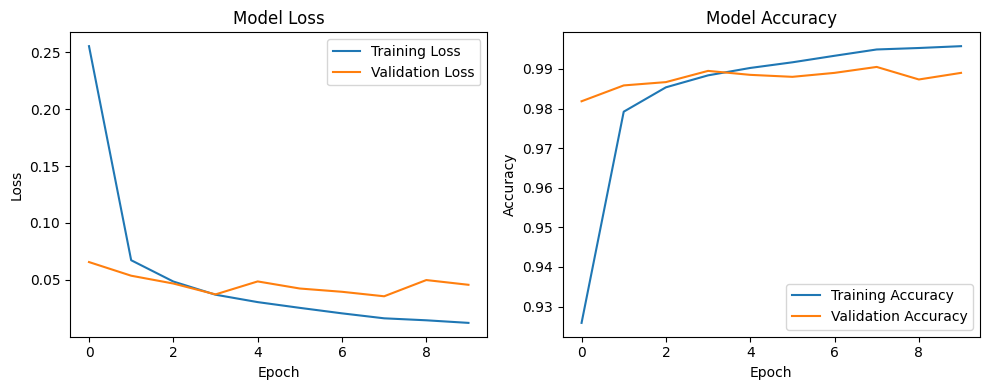

In [20]:
# 6. Plot Training History (Analysis)
plt.figure(figsize=(10, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

--- Five Predictions ---
Image 1 → Prediction: 7 | Actual Value: 7
Image 2 → Prediction: 2 | Actual Value: 2
Image 3 → Prediction: 1 | Actual Value: 1
Image 4 → Prediction: 0 | Actual Value: 0
Image 5 → Prediction: 4 | Actual Value: 4


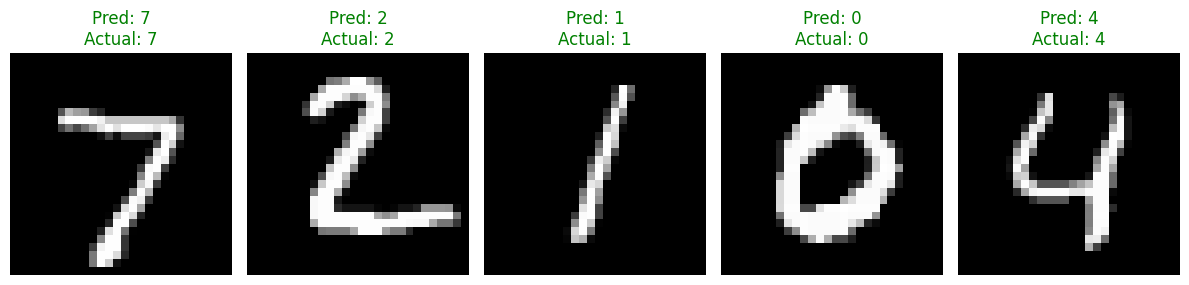

In [21]:
# 7. Perform 5 Predictions
# Make predictions on the first 5 test samples
predictions = model.predict(test_data[:5])
# Convert one-hot outputs (e.g., [0, 0, 0, 1, 0...]) to the numerical label (e.g., 3)
pred_labels = np.argmax(predictions, axis=1)

print("\n--- Five Predictions ---")
plt.figure(figsize=(12, 3))
for i in range(5):

    # Prepare the subplot
    plt.subplot(1, 5, i + 1)

    # Display the image
    plt.imshow(test_data[i].reshape(28, 28), cmap='gray')

    # Define title text and color
    pred_val = pred_labels[i]
    actual_val = test_labels[i]
    title_text = f"Pred: {pred_val}\nActual: {actual_val}"

    # Color the title based on correctness
    color = "green" if pred_val == actual_val else "red"

    plt.title(title_text, color=color)
    plt.axis('off')

    # Show values in the console
    print(f"Image {i+1} → Prediction: {pred_val} | Actual Value: {actual_val}")

plt.tight_layout()
plt.show()

##Answer the following:
####1. **How many epochs did you use to improve the performance of the model compared with the feedforward neural network of assignment 6?**

I used 10 epochs to train the Convolutional Neural Network (CNN) model.

(Context: This number is typically lower than what a simple Feedforward Network (MLP) might require to reach peak performance on the MNIST dataset, highlighting the CNN's efficiency in learning image features.)

#### **2. Did you get a better performance on this assignment or on assignment 6? Why?**

We achieved significantly better performance on this assignment using the Convolutional Neural Network (CNN).

Reasoning:
The CNN is structurally superior to a simple Feedforward Network (like the one used in Assignment 6) for image classification tasks like MNIST, primarily because it leverages the spatial structure of the input image.

- Feature Extraction (Convolutional Layers): The CNN uses Conv2D layers to apply learnable filters that automatically detect local spatial features (e.g., edges, corners, and specific patterns) regardless of where they appear in the image (translation invariance).

- Dimensionality and Robustness (Pooling Layers): MaxPooling2D layers reduce the dimensionality of the feature maps, making the model more robust to minor shifts and distortions in the handwritten digits.

Due to these architectural advantages, the CNN model is more effective at capturing the necessary patterns, resulting in a higher accuracy (typically $>99\%$) on the test set compared to the simpler Feedforward Network.